<a href="https://colab.research.google.com/github/rhmi27/Patient_churn_prediction/blob/main/Patient_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing necessary libraries for analysis.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from imblearn.over_sampling import SMOTE
!pip install catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


**Importing dataset from Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab_Datasets/patient_churn_dataset.csv'
df = pd.read_csv(file_path)

df.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


**Reviewing Dataset information.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   object 
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   object 
 3   State                       2000 non-null   object 
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   object 
 6   Insurance_Type              2000 non-null   object 
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   object 
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 

**Dropping PatientID column, and distributing Specialty and Insurance Type across columns.**

In [ ]:
df.isnull().sum()
df = df.drop(["PatientID"], axis=1)

df["Gender"].unique()
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df = df.drop("State", axis= 1)
df["Specialty"].unique()
df = pd.get_dummies(df, columns=["Specialty"], drop_first=True, dtype=int)
df["Insurance_Type"].unique()
df = pd.get_dummies(df, columns= ["Insurance_Type"], drop_first=True, dtype=int)
df["Last_Interaction_Date"] = pd.to_datetime(df["Last_Interaction_Date"])
Today = pd.to_datetime("today")
df = df.drop(["Last_Interaction_Date"], axis=1)

df.head()

,Age,Gender,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,...,Churned,Specialty_Family Medicine,Specialty_General Practice,Specialty_Internal Medicine,Specialty_Neurology,Specialty_Orthopedics,Specialty_Pediatrics,Insurance_Type_Medicare,Insurance_Type_Private,Insurance_Type_Self-Pay
0,41,1,62,1,0,564,3.5,4.9,3.8,4.2,...,1,0,0,0,0,0,1,0,0,0
1,43,1,44,7,4,254,2.6,3.1,4.7,4.3,...,1,0,0,1,0,0,0,0,0,1
2,21,0,120,15,5,89,1.6,4.4,2.1,4.7,...,0,0,0,1,0,0,0,0,0,0
3,65,0,118,10,3,135,2.6,4.3,4.3,4.9,...,1,0,1,0,0,0,0,0,1,0
4,18,1,70,5,4,696,2.2,4.0,4.1,4.4,...,1,0,0,0,0,0,0,0,0,0


## Data Overview and Initial Insights

Performing a comprehensive exploratory data analysis (EDA) to understand data distributions, identify potential trends, and generate initial insights related to patient churn. This includes analysing the distribution of the 'Churned' variable, demographic breakdowns (Age, Gender), service usage patterns (Visits_Last_Year, Missed_Appointments, Days_Since_Last_Visit), satisfaction metrics, and financial aspects (Avg_Out_Of_Pocket_Cost, Billing_Issues). Trend analysis will focus on how churn correlates with Tenure_Months and other time-related features, and how various factors influence churn. Visualizations for a dashboard will be created during this step.


**Display descriptive statistics for all numerical columns. This provides a general overview of the data's central tendency, dispersion, and shape.**



In [ ]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

Descriptive statistics for numerical columns:
               Age       Gender  Tenure_Months  Visits_Last_Year  \
count  2000.000000  2000.000000    2000.000000       2000.000000   
mean     52.856500     0.492000      60.733500          7.614000   
std      15.836487     0.500061      35.111293          4.672143   
min      18.000000     0.000000       1.000000          0.000000   
25%      41.000000     0.000000      30.000000          4.000000   
50%      54.000000     0.000000      60.000000          8.000000   
75%      65.000000     1.000000      92.250000         12.000000   
max      90.000000     1.000000     120.000000         15.000000   

       Missed_Appointments  Days_Since_Last_Visit  Overall_Satisfaction  \
count          2000.000000            2000.000000           2000.000000   
mean              2.028000             366.130000              3.255000   
std               1.699312             212.890277              1.008595   
min               0.000000               

**Calculate and display the value counts for the 'Churned' column to understand the distribution of the target variable, which is essential for churn prediction.**



In [ ]:
print("Value counts for 'Churned' column:")
print(df['Churned'].value_counts())

Value counts for 'Churned' column:
Churned
1    1367
0     633
Name: count, dtype: int64


**Visualize the distribution of the 'Churned' variable, broken down by 'Gender', using a count plot to easily compare churn rates between genders.**



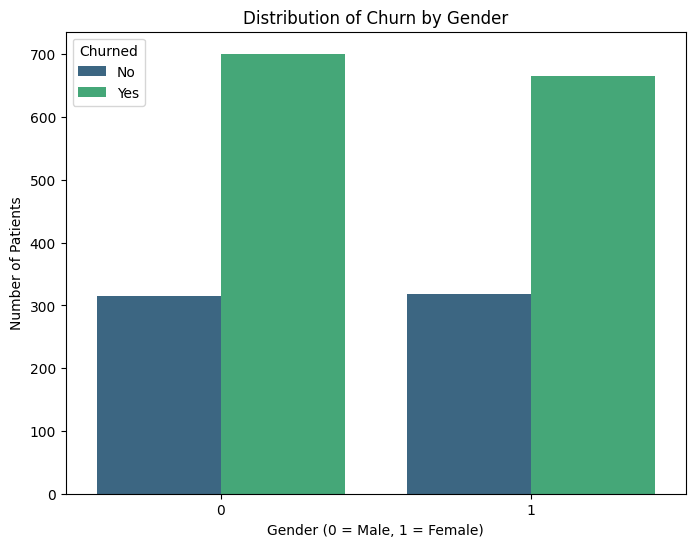

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', hue='Churned', palette='viridis')
plt.title('Distribution of Churn by Gender')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Number of Patients')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.show()

**Generate a histogram for the 'Age' column to visualize the age distribution of patients, which is a key demographic feature.**



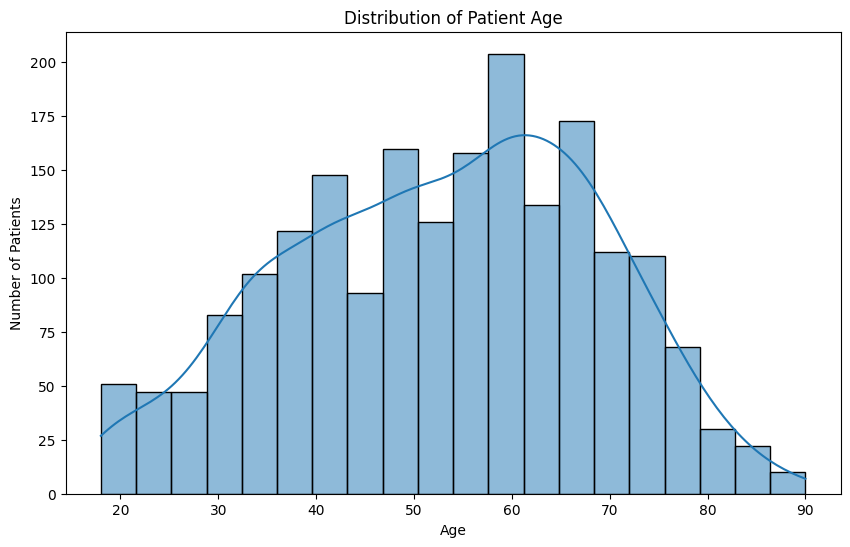

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

**Create a box plot to visualize the relationship between 'Age' and 'Churned' status, which will help identify any age-related patterns in patient churn.**



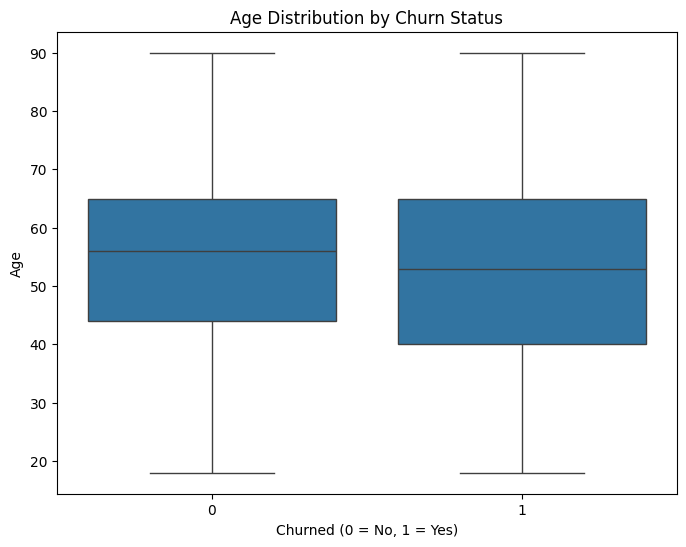

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churned', y='Age')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

**Plot histograms for 'Tenure_Months', 'Visits_Last_Year', 'Missed_Appointments', 'Days_Since_Last_Visit', and 'Avg_Out_Of_Pocket_Cost' to observe their distributions.**



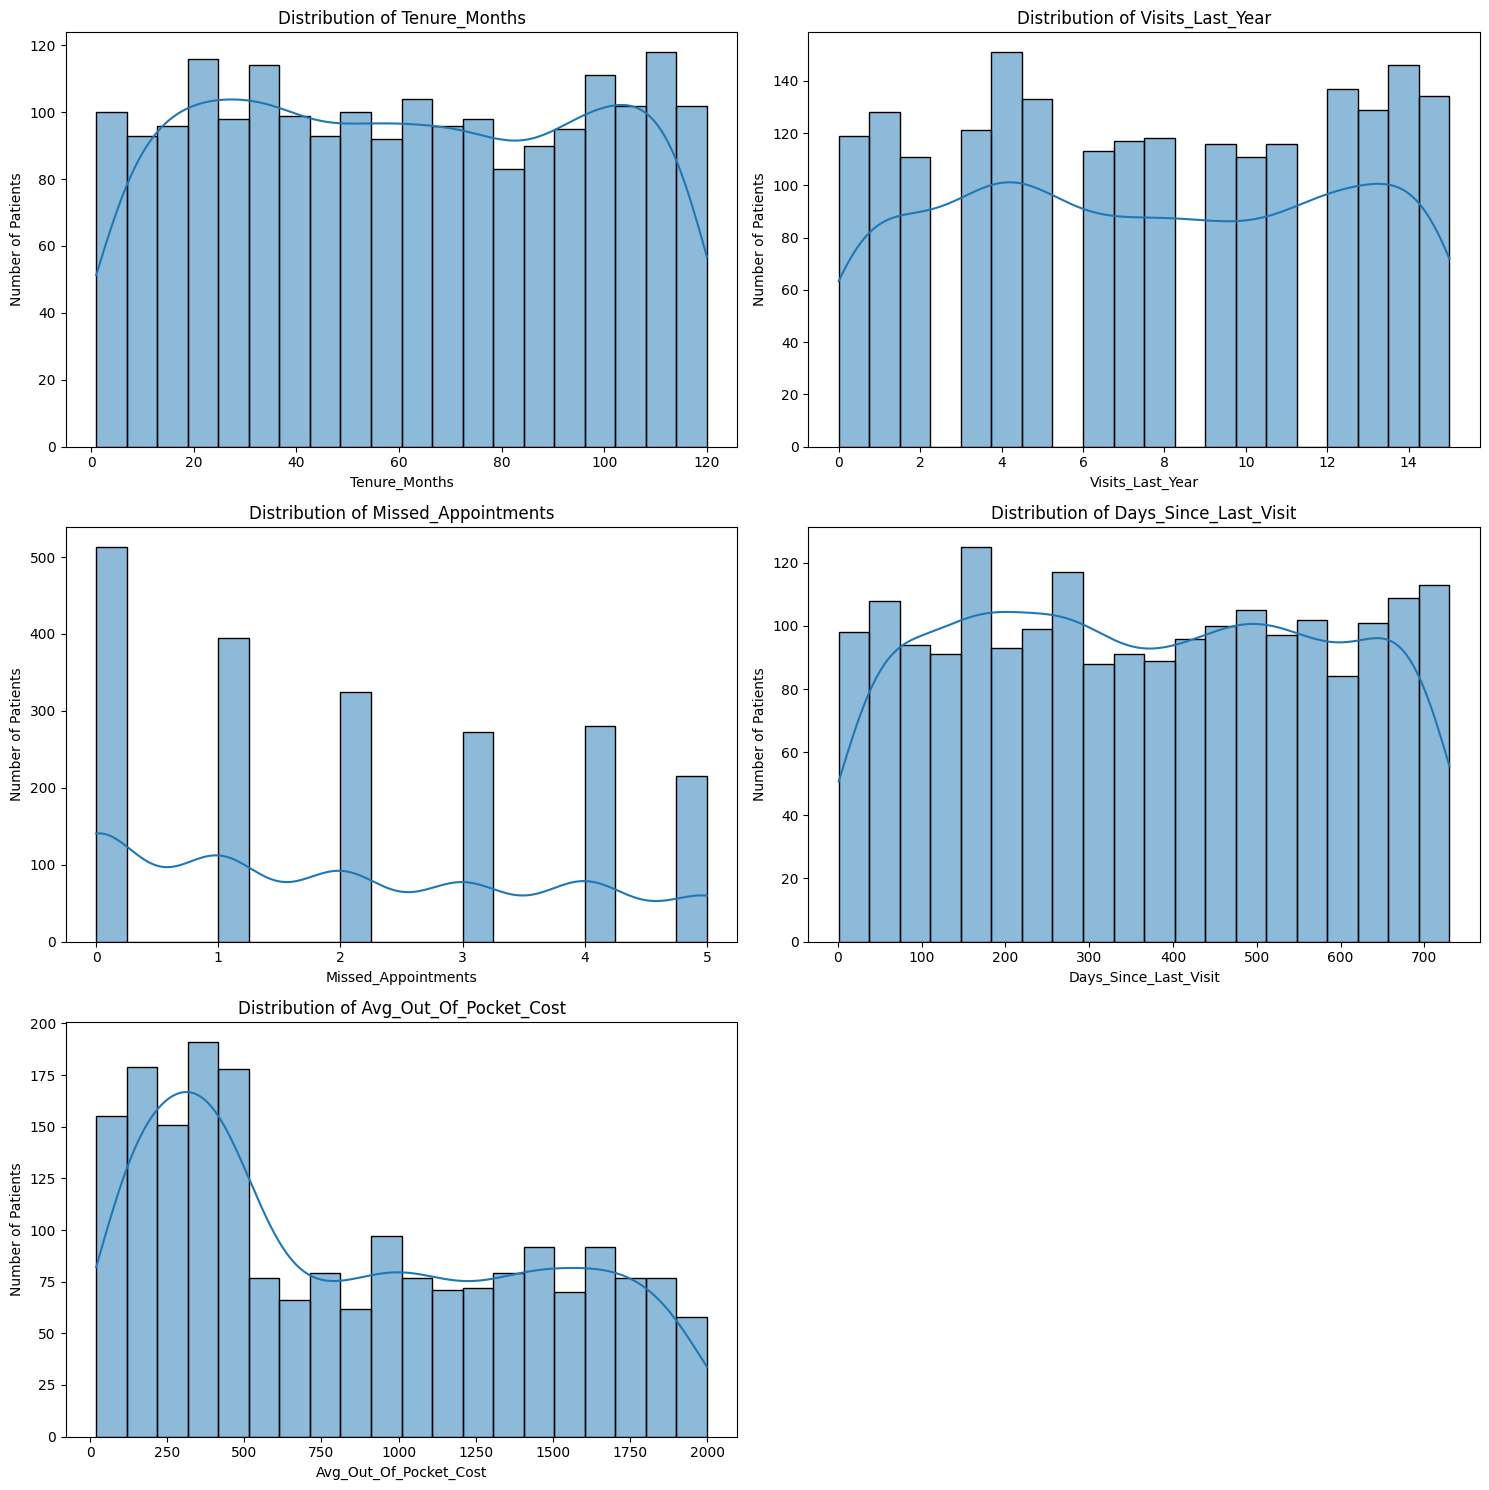

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

columns_to_plot = ['Tenure_Months', 'Visits_Last_Year', 'Missed_Appointments', 'Days_Since_Last_Visit', 'Avg_Out_Of_Pocket_Cost']

for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Patients')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Create a correlation heatmap to visualize the correlation matrix of all numerical features, including 'Churned', to identify features strongly related to churn.**



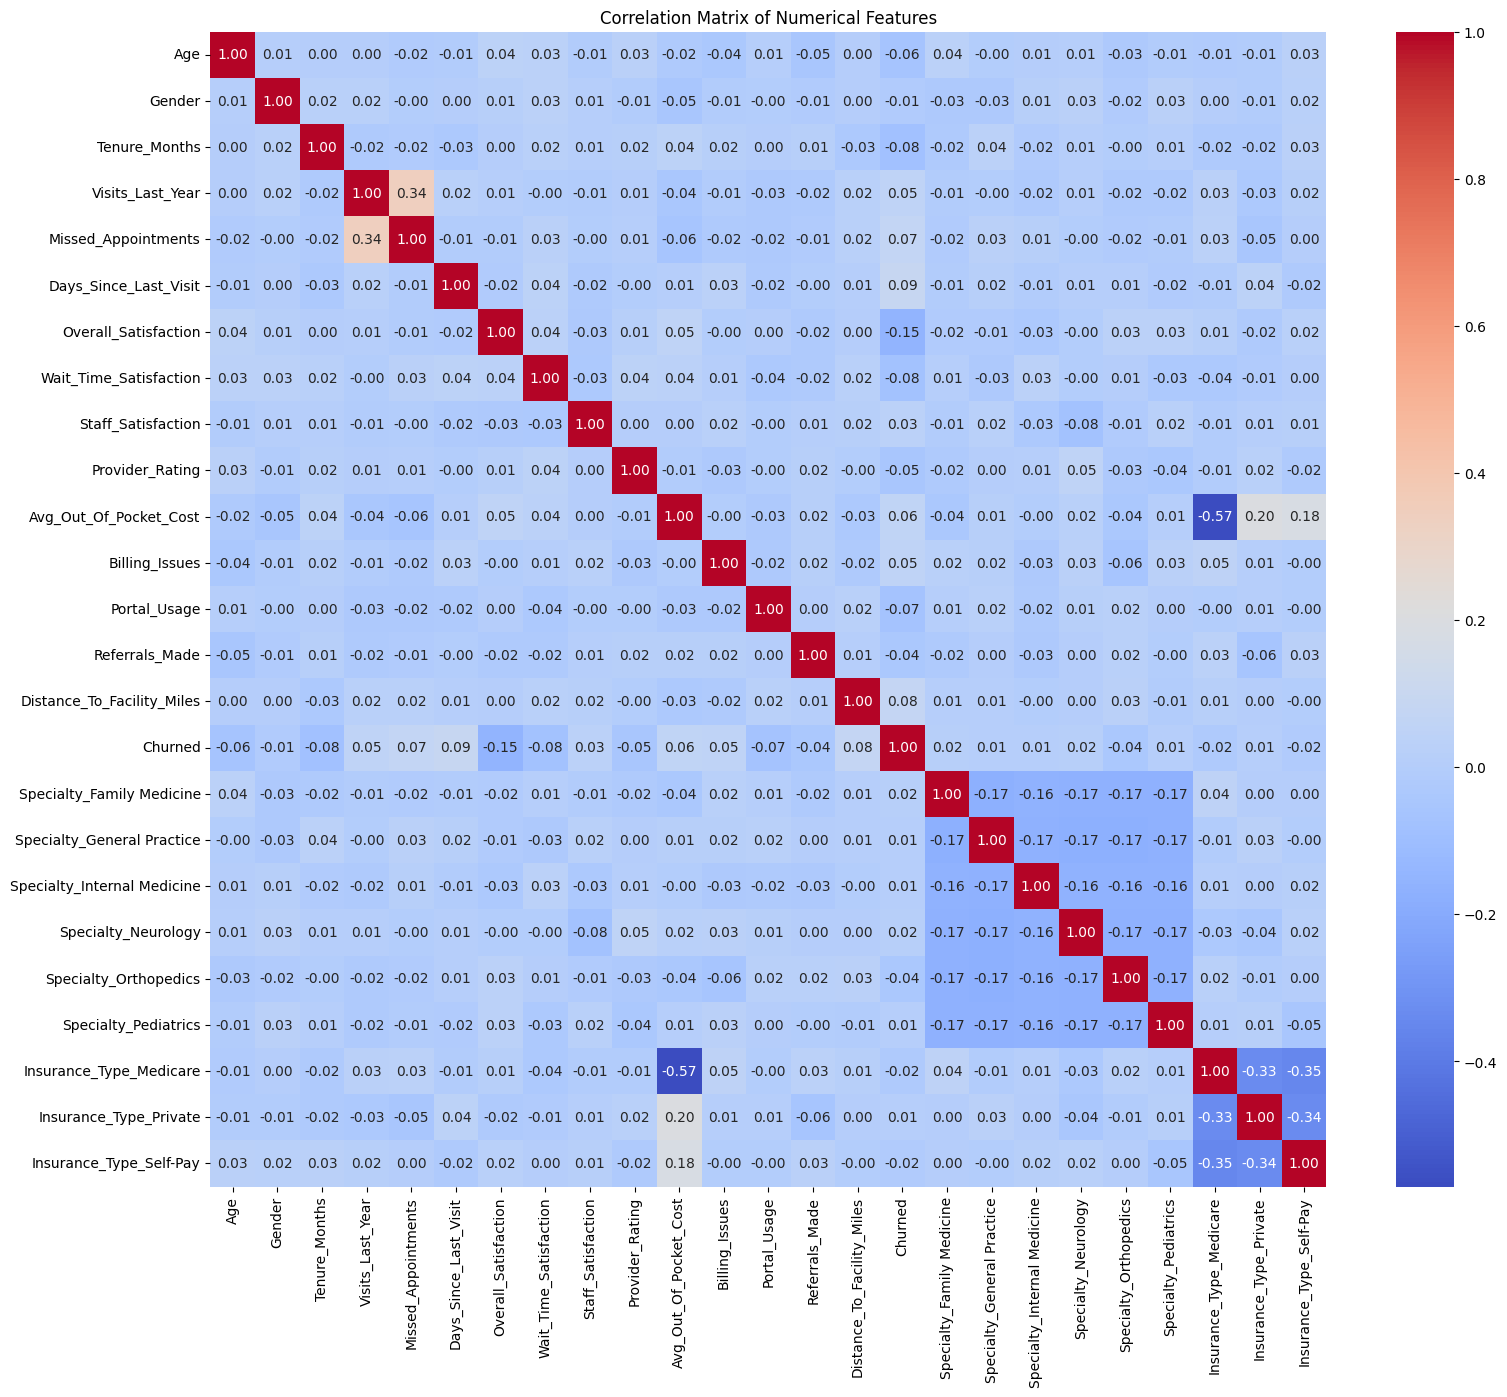

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Generate box plots or violin plots for 'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', and 'Provider_Rating' against the 'Churned' variable. This will help understand how satisfaction scores influence patient churn.**



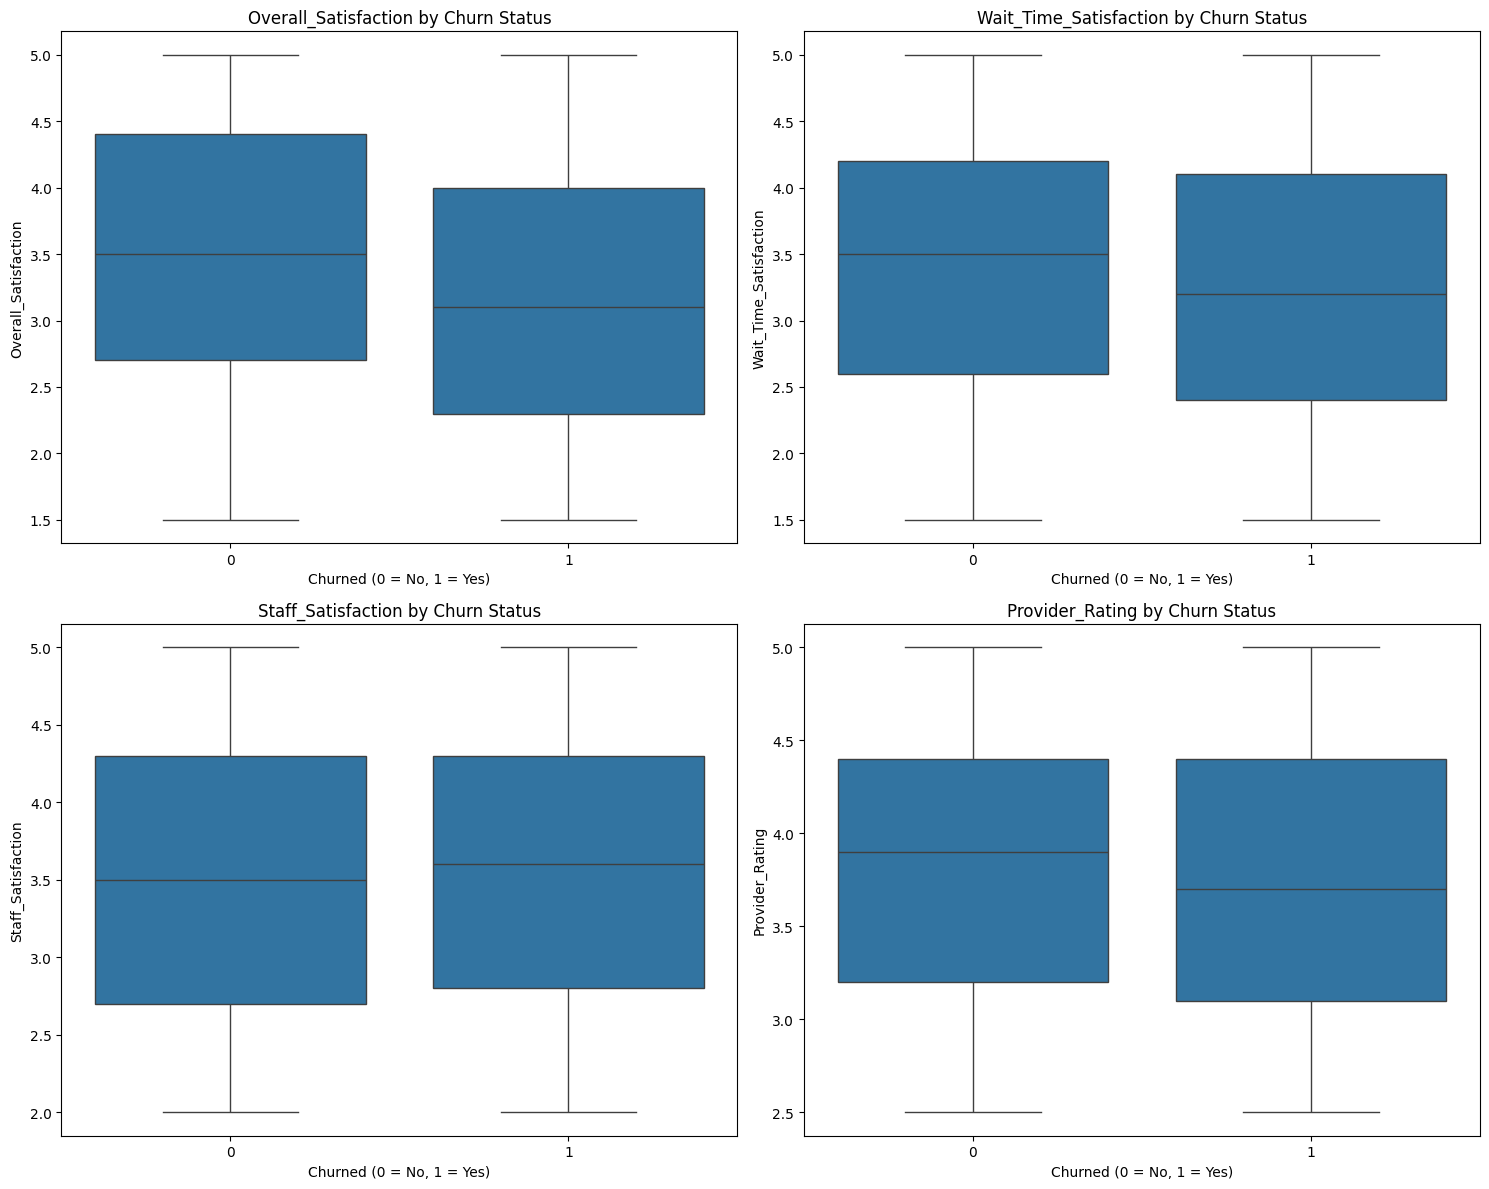

In [ ]:
satisfaction_cols = ['Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', 'Provider_Rating']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    sns.boxplot(data=df, x='Churned', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Churn Status')
    axes[i].set_xlabel('Churned (0 = No, 1 = Yes)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

**Create count plots for 'Billing_Issues' and 'Portal_Usage' against 'Churned' status to visualize their relationship with patient churn.**



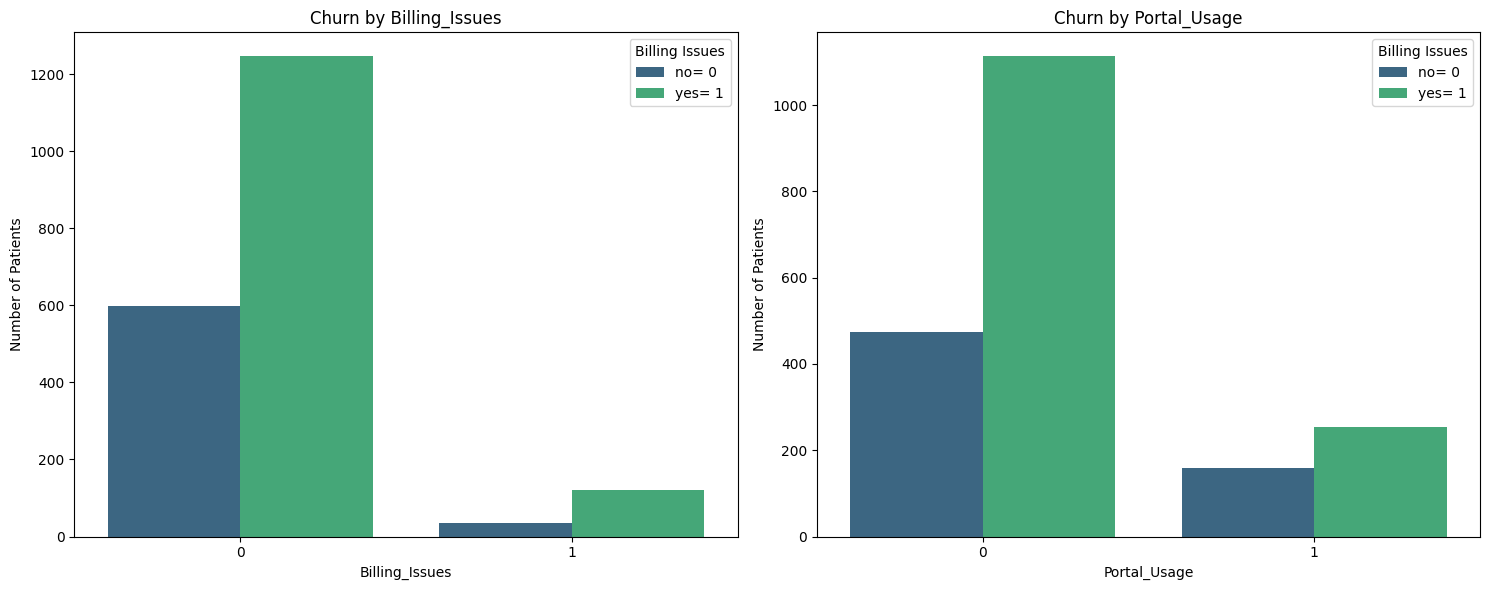

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes = axes.flatten()

service_cols = ['Billing_Issues', 'Portal_Usage']

for i, col in enumerate(service_cols):
    sns.countplot(data=df, x=col, hue='Churned', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Patients')
    axes[i].legend(title='Churned', labels=['No', 'Yes'])
    axes[i].legend(title= 'Billing Issues', labels=['no= 0', 'yes= 1'])

plt.tight_layout()
plt.show()

**Display average 'Tenure_Months' for churned and non-churned patients, to identify if there's a notable difference between the groups.**



In [ ]:
print("Average Tenure_Months for churned and non-churned patients:")
print(df.groupby('Churned')['Tenure_Months'].mean())

Average Tenure_Months for churned and non-churned patients:
Churned
0    64.846761
1    58.828822
Name: Tenure_Months, dtype: float64


## Feature Engineering and Preprocessing for ML

Review and refine existing engineered features, identify any other potential features, split the dataset into training and testing sets, address class imbalance using SMOTE, and apply feature scaling to numerical predictors.


**Verify the presence of engineered features and examine them.**
**Displaying the head of the DataFrame `df` allows us to check for the specified columns (`Missed_rate`, `visits_freq`, `Recency_Score`, `Satisfaction_Variance`, `Wait_vs_Staff_Gap`) and observe their values.**



In [ ]:
df['Missed_rate'] = df['Missed_Appointments'] / df['Visits_Last_Year'].replace(0, 1)
df['visits_freq'] = df['Visits_Last_Year'] / df['Tenure_Months'].replace(0, 1)
df['Recency_Score'] = df['Days_Since_Last_Visit'] / 730 # Assuming 2 years as max days
df['Satisfaction_Variance'] = df[['Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', 'Provider_Rating']].std(axis=1)
df['Wait_vs_Staff_Gap'] = df['Wait_Time_Satisfaction'] - df['Staff_Satisfaction']

print("Displaying head of DataFrame to verify engineered features:")
print(df[['Missed_rate', 'visits_freq', 'Recency_Score', 'Satisfaction_Variance', 'Wait_vs_Staff_Gap']].head())

Displaying head of DataFrame to verify engineered features:
   Missed_rate  visits_freq  Recency_Score  Satisfaction_Variance  \
0     0.000000     0.016129       0.772603               0.605530   
1     0.571429     0.159091       0.347945               0.987843   
2     0.333333     0.125000       0.121918               1.576917   
3     0.300000     0.084746       0.184932               0.991211   
4     0.800000     0.071429       0.953425               0.997914   

   Wait_vs_Staff_Gap  
0                1.1  
1               -1.6  
2                2.3  
3                0.0  
4               -0.1  


**Create a new DataFrame `X` containing all features (excluding 'Churned') and a Series `y` containing the 'Churned' target variable. This is a standard practice for preparing data for machine learning models.**



In [ ]:
X = df.drop('Churned', axis=1)
y = df['Churned']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2000, 29)
Shape of y: (2000,)


**Split the `X` and `y` data into training and testing sets using `train_test_split`. This prepares the data for model training and evaluation.**



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1600, 29)
Shape of X_test: (400, 29)
Shape of y_train: (1600,)
Shape of y_test: (400,)


**Apply SMOTE to the training data (`X_train`, `y_train`) to address class imbalance. This will create `X_resampled` and `y_resampled` with a balanced class distribution.**



In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)
print("Value counts of y_resampled:\n", y_resampled.value_counts())

Shape of X_resampled: (2146, 29)
Shape of y_resampled: (2146,)
Value counts of y_resampled:
 Churned
1    1073
0    1073
Name: count, dtype: int64


**Identify the numerical columns in `X_resampled` that need scaling. This involves selecting columns with numerical data types to ensure only appropriate features are scaled.**



In [ ]:
numerical_cols = X_resampled.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns identified for scaling:", numerical_cols.tolist())

Numerical columns identified for scaling: ['Age', 'Gender', 'Tenure_Months', 'Visits_Last_Year', 'Missed_Appointments', 'Days_Since_Last_Visit', 'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', 'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues', 'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles', 'Specialty_Family Medicine', 'Specialty_General Practice', 'Specialty_Internal Medicine', 'Specialty_Neurology', 'Specialty_Orthopedics', 'Specialty_Pediatrics', 'Insurance_Type_Medicare', 'Insurance_Type_Private', 'Insurance_Type_Self-Pay', 'Missed_rate', 'visits_freq', 'Recency_Score', 'Satisfaction_Variance', 'Wait_vs_Staff_Gap']


**Initialize a `StandardScaler` from `sklearn.preprocessing`. This prepares the scaler for subsequent use in feature scaling.**



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
print("StandardScaler initialized.")

StandardScaler initialized.


**Fit the `StandardScaler` to the numerical columns of `X_resampled` and then transform both `X_resampled` and `X_test` using the fitted scaler. This will scale the features to have a mean of 0 and a standard deviation of 1.**



In [ ]:
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features in X_resampled and X_test have been scaled.")
print("First 5 rows of scaled X_resampled numerical columns:\n", X_resampled[numerical_cols].head())

Numerical features in X_resampled and X_test have been scaled.
First 5 rows of scaled X_resampled numerical columns:
         Age    Gender  Tenure_Months  Visits_Last_Year  Missed_Appointments  \
0  0.052618  1.138063       0.088826          1.479182             0.714584   
1  0.314305  1.138063      -0.886596         -0.530308             0.714584   
2  0.248883  1.138063      -0.058965          1.032628             1.331933   
3 -1.059551 -0.878686       0.739108         -1.423414            -1.137465   
4  0.772257  1.138063       1.182481          0.362799            -1.137465   

   Days_Since_Last_Visit  Overall_Satisfaction  Wait_Time_Satisfaction  \
0               0.663258             -0.034677                0.071695   
1               1.202176             -1.682138                1.312245   
2               1.065083              0.171256                1.312245   
3              -0.821129             -0.240609                1.002108   
4               0.133795             

## Churn Prediction Model Building

Develop and train multiple machine learning models (Logistic Regression, Random Forest, XGBoost, CatBoost) to predict patient churn. Evaluate model performance using appropriate metrics like accuracy, precision, recall, F1-score, and AUC-ROC, paying close attention to the recall of the churn class.


**Initialize and train a `LogisticRegression` model using the `X_resampled` and `y_resampled` data, as prepared in the previous steps. This will fit the model to the balanced training data.**



In [ ]:
model_lr = LogisticRegression(random_state=42, solver='liblinear')
model_lr.fit(X_resampled, y_resampled)
print("Logistic Regression model trained.")

Logistic Regression model trained.


**Make predictions on `X_test` using the trained Logistic Regression model and then display the `classification_report` and `confusion_matrix` to evaluate its performance.**



In [ ]:
y_pred_lr = model_lr.predict(X_test)
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.40      0.39      0.39       106
           1       0.78      0.79      0.79       294

    accuracy                           0.69       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.68      0.69      0.68       400

Confusion Matrix for Logistic Regression:
[[ 41  65]
 [ 61 233]]


**Initialize and train a `RandomForestClassifier` model using the `X_resampled` and `y_resampled` data. This will fit the model to the balanced training data.**



In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_resampled, y_resampled)
print("Random Forest Classifier model trained.")

Random Forest Classifier model trained.


**Make predictions on `X_test` using the trained Random Forest model and then display the `classification_report` and `confusion_matrix` to evaluate its performance.**



In [ ]:
y_pred_rf = model_rf.predict(X_test)
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.40      0.33      0.36       106
           1       0.77      0.82      0.80       294

    accuracy                           0.69       400
   macro avg       0.59      0.58      0.58       400
weighted avg       0.67      0.69      0.68       400

Confusion Matrix for Random Forest:
[[ 35  71]
 [ 52 242]]


**Initialize and train an `XGBClassifier` model using the `X_resampled` and `y_resampled` data. This will fit the model to the balanced training data.**



In [ ]:
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_resampled, y_resampled)
print("XGBoost Classifier model trained.")

XGBoost Classifier model trained.


**Make predictions on `X_test` using the trained XGBoost model and then display the `classification_report` and `confusion_matrix` to evaluate its performance.**



In [ ]:
y_pred_xgb = model_xgb.predict(X_test)
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix for XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.38      0.37      0.38       106
           1       0.78      0.79      0.78       294

    accuracy                           0.68       400
   macro avg       0.58      0.58      0.58       400
weighted avg       0.67      0.68      0.67       400

Confusion Matrix for XGBoost:
[[ 39  67]
 [ 63 231]]


**Initialize and train a `CatBoostClassifier` model using the `X_resampled` and `y_resampled` data. Setting `verbose=0` will suppress the training output.**



In [ ]:
model_cb = CatBoostClassifier(random_state=42, verbose=0)
model_cb.fit(X_resampled, y_resampled)
print("CatBoost Classifier model trained.")

CatBoost Classifier model trained.


**Make predictions on `X_test` using the trained CatBoost model and then display the `classification_report` and `confusion_matrix` to evaluate its performance.**



In [ ]:
y_pred_cb = model_cb.predict(X_test)
print("Classification Report for CatBoost:")
print(classification_report(y_test, y_pred_cb))
print("Confusion Matrix for CatBoost:")
print(confusion_matrix(y_test, y_pred_cb))

Classification Report for CatBoost:
              precision    recall  f1-score   support

           0       0.36      0.34      0.35       106
           1       0.77      0.79      0.78       294

    accuracy                           0.67       400
   macro avg       0.57      0.56      0.56       400
weighted avg       0.66      0.67      0.66       400

Confusion Matrix for CatBoost:
[[ 36  70]
 [ 63 231]]


## Identify Key Churn Drivers and Insights

Analyze the trained models to identify the most significant factors contributing to patient churn. Utilize feature importance from tree-based models to understand key drivers.


**Extract feature importances from the trained RandomForestClassifier model (`model_rf`), store them in a pandas Series with feature names as the index, and then display the top 10 most important features. This will help identify key drivers of churn according to this model.**



In [ ]:
feature_importances_rf = pd.Series(model_rf.feature_importances_, index=X_resampled.columns)
print("Top 10 Feature Importances from RandomForestClassifier:")
print(feature_importances_rf.nlargest(10))

Top 10 Feature Importances from RandomForestClassifier:
Overall_Satisfaction          0.071684
Distance_To_Facility_Miles    0.062640
Avg_Out_Of_Pocket_Cost        0.060183
Satisfaction_Variance         0.059495
Provider_Rating               0.059108
Tenure_Months                 0.057244
Age                           0.056822
Wait_Time_Satisfaction        0.055412
Wait_vs_Staff_Gap             0.052908
Recency_Score                 0.052662
dtype: float64


**Extract and print the feature importances from the trained `XGBClassifier` model (`model_xgb`), store them in a pandas Series with feature names as the index, and then display the top 10 most important features. This will help identify key drivers of churn according to this model.**



In [ ]:
feature_importances_xgb = pd.Series(model_xgb.feature_importances_, index=X_resampled.columns)
print("Top 10 Feature Importances from XGBoostClassifier:")
print(feature_importances_xgb.nlargest(10))

Top 10 Feature Importances from XGBoostClassifier:
Specialty_Orthopedics          0.123671
Specialty_Neurology            0.090834
Specialty_Internal Medicine    0.064993
Specialty_General Practice     0.058894
Specialty_Family Medicine      0.051876
Specialty_Pediatrics           0.050302
Billing_Issues                 0.049151
Missed_Appointments            0.048069
Insurance_Type_Private         0.036613
Insurance_Type_Medicare        0.028935
dtype: float32


**Extract and print the feature importances from the trained `CatBoostClassifier` model (`model_cb`), store them in a pandas Series with feature names as the index, and then display the top 10 most important features. This will help identify key drivers of churn according to this model.**



In [ ]:
feature_importances_cb = pd.Series(model_cb.get_feature_importance(), index=X_resampled.columns)
print("Top 10 Feature Importances from CatBoostClassifier:")
print(feature_importances_cb.nlargest(10))

Top 10 Feature Importances from CatBoostClassifier:
Missed_rate                   7.652363
Missed_Appointments           6.996390
Overall_Satisfaction          6.149699
Satisfaction_Variance         5.743289
Distance_To_Facility_Miles    5.563430
Avg_Out_Of_Pocket_Cost        5.561616
Provider_Rating               5.520795
Tenure_Months                 5.307069
Age                           5.192973
Wait_Time_Satisfaction        4.612622
dtype: float64


Generating the `requirements.txt` file from the
current Colab environment. This will list all installed packages and their versions, which are necessary for others to reproduce your environment.

In [ ]:
!pip freeze > requirements.txt
print("requirements.txt has been generated.")

requirements.txt has been generated.
